# Cell 1 — QKA Repair & Diagnostic Experiment

# QKA Repair Experiment for NA-HQKVE-IDS

This notebook isolates the **Quantum Kernel Alignment (QKA)** branch that collapsed in the Paper Core experiment.

It is intentionally smaller than the full IDS notebook. Its purpose is to answer:

1. Is the baseline fixed fidelity quantum kernel healthy?
2. Does the trainable feature map actually change the kernel matrix?
3. Does kernel-target alignment improve after training?
4. Is QKA failure caused by:
   - parameterization,
   - initialization,
   - optimizer choice,
   - insufficient optimizer iterations,
   - kernel concentration,
   - or an unsuitable latent representation?
5. Which repaired QKA configuration is safe to put back into the publication notebook?

### Four main repair variants
- **R1:** 4Q, shared trainable parameter, exact statevector kernel, COBYLA
- **R2:** 4Q, shared trainable parameter, exact statevector kernel, SPSA
- **R3:** 6Q, shared trainable parameter, exact statevector kernel, COBYLA
- **R4:** 6Q, per-qubit trainable parameters, exact statevector kernel, best optimizer

The notebook records:
- train/test F1, MCC, ROC-AUC, PR-AUC
- SVC loss
- centered kernel-target alignment (CKTA)
- within-class and between-class similarity
- kernel variance
- eigenvalue spectrum
- condition number
- optimizer convergence
- parameter sensitivity
- runtime

### Repair success criterion
A QKA configuration is considered healthy enough for the full experiment when it:
- no longer produces constant predictions,
- has ROC-AUC meaningfully above 0.50,
- has MCC above 0,
- improves alignment or SVC loss relative to initialization,
- and does not catastrophically degrade relative to the fixed quantum kernel.

In [1]:
# Cell 2 — Install current Qiskit ML stack
!pip -q install \
    "qiskit>=2.2" \
    "qiskit-machine-learning>=0.9.0" \
    "qiskit-aer>=0.17"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00


In [2]:
# Cell 3 — Imports, versions and seed
import time, json, random, warnings, platform
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import eigvalsh
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.svm import SVC
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import qiskit
import qiskit_machine_learning
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map

from qiskit_machine_learning.kernels import (
    FidelityStatevectorKernel,
    TrainableFidelityStatevectorKernel
)
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer
from qiskit_machine_learning.optimizers import COBYLA, SPSA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", platform.python_version())
print("Qiskit:", qiskit.__version__)
print("Qiskit Machine Learning:", qiskit_machine_learning.__version__)
print("Torch:", torch.__version__)
print("Device:", DEVICE)


Python: 3.12.13
Qiskit: 2.5.2
Qiskit Machine Learning: 0.9.0
Torch: 2.11.0+cu128
Device: cuda


In [3]:
# Cell 4 — Repair experiment configuration
# Start with DIAGNOSTIC. Increase only after the notebook works end-to-end.
PROFILE = "DIAGNOSTIC"
# PROFILE = "REPAIR_FULL"

if PROFILE == "DIAGNOSTIC":
    TRAIN_PER_CLASS = 40
    TEST_PER_CLASS = 100
    AE_EPOCHS = 25
    COBYLA_ITERS = 30
    SPSA_ITERS = 25
    INIT_POINTS_SHARED = [0.0, np.pi/4, np.pi/2, 3*np.pi/4]
else:
    TRAIN_PER_CLASS = 100
    TEST_PER_CLASS = 250
    AE_EPOCHS = 60
    COBYLA_ITERS = 80
    SPSA_ITERS = 60
    INIT_POINTS_SHARED = [
        0.0, np.pi/8, np.pi/4, np.pi/2,
        3*np.pi/4, np.pi
    ]

TOP_MI = 25
TOP_FINAL = 12
QUBIT_OPTIONS = [4, 6]

# From the successful Paper Core feature-selection output.
PAPER_CORE_FEATURES = [
    "sttl", "ct_state_ttl", "state_INT", "ct_dst_sport_ltm",
    "synack", "tcprtt", "dbytes", "smean",
    "ct_srv_dst", "sbytes", "rate", "dmean"
]

print("PROFILE:", PROFILE)
print("Training samples/class:", TRAIN_PER_CLASS)
print("Test samples/class:", TEST_PER_CLASS)


PROFILE: DIAGNOSTIC
Training samples/class: 40
Test samples/class: 100


In [ ]:
# Cell 5 — Upload UNSW-NB15 training and testing CSVs
from google.colab import files

print("Upload BOTH:")
print("  UNSW_NB15_training-set.csv")
print("  UNSW_NB15_testing-set.csv")

uploaded = files.upload()

csv_files = list(Path("/content").glob("*.csv"))

def find_csv(keys):
    for f in csv_files:
        n = f.name.lower()
        if all(k in n for k in keys):
            return str(f)
    return None

TRAIN_PATH = find_csv(["training"]) or find_csv(["train"])
TEST_PATH = find_csv(["testing"]) or find_csv(["test"])

if TRAIN_PATH is None or TEST_PATH is None:
    raise FileNotFoundError("Could not detect UNSW-NB15 training/testing CSV files.")

print("Train:", TRAIN_PATH)
print("Test :", TEST_PATH)


In [4]:
# Cell 6 — Load and clean binary IDS data
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the paths to your datasets
TRAIN_PATH = '/content/drive/MyDrive/PhD_Work/Dataset/UNSW_NB15/UNSW_NB15_training-set.csv'
TEST_PATH = '/content/drive/MyDrive/PhD_Work/Dataset/UNSW_NB15/UNSW_NB15_testing-set.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

for df in (train_df, test_df):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

DROP = ["id", "attack_cat"]

X_train_raw = train_df.drop(
    columns=[c for c in DROP + ["label"] if c in train_df.columns]
).copy()
X_test_raw = test_df.drop(
    columns=[c for c in DROP + ["label"] if c in test_df.columns]
).copy()

X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns)

y_train = train_df["label"].astype(int).to_numpy()
y_test = test_df["label"].astype(int).to_numpy()

cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

X_train_raw[num_cols] = X_train_raw[num_cols].apply(pd.to_numeric, errors="coerce")
X_test_raw[num_cols] = X_test_raw[num_cols].apply(pd.to_numeric, errors="coerce")

medians = X_train_raw[num_cols].median()
X_train_raw[num_cols] = X_train_raw[num_cols].fillna(medians)
X_test_raw[num_cols] = X_test_raw[num_cols].fillna(medians)

for c in cat_cols:
    X_train_raw[c] = X_train_raw[c].fillna("MISSING").astype(str)
    X_test_raw[c] = X_test_raw[c].fillna("MISSING").astype(str)

print("Train:", X_train_raw.shape, np.bincount(y_train))
print("Test :", X_test_raw.shape, np.bincount(y_test))


Mounted at /content/drive
Train: (82332, 42) [37000 45332]
Test : (175341, 42) [ 56000 119341]


In [5]:
# Cell 7 — Recreate Paper Core preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    verbose_feature_names_out=False,
)

Xtr = preprocessor.fit_transform(X_train_raw)
Xte = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out()

Xtr = pd.DataFrame(Xtr, columns=feature_names)
Xte = pd.DataFrame(Xte, columns=feature_names)

print("Preprocessed:", Xtr.shape, Xte.shape)


Preprocessed: (82332, 190) (175341, 190)


In [6]:
# Cell 8 — Use Paper Core features when available, otherwise recompute
available = [f for f in PAPER_CORE_FEATURES if f in Xtr.columns]

if len(available) == TOP_FINAL:
    selected_features = PAPER_CORE_FEATURES.copy()
    print("Using the exact 12 Paper Core selected features.")
else:
    print("Some Paper Core feature names are unavailable after encoding.")
    print("Recomputing MI + XGBoost selection.")

    mi = mutual_info_classif(Xtr, y_train, random_state=SEED)
    mi_s = pd.Series(mi, index=Xtr.columns).sort_values(ascending=False)
    mi_features = mi_s.head(TOP_MI).index.tolist()

    fs = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        tree_method="hist",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1
    )
    fs.fit(Xtr[mi_features], y_train)
    imp = pd.Series(
        fs.feature_importances_, index=mi_features
    ).sort_values(ascending=False)
    selected_features = imp.head(TOP_FINAL).index.tolist()

print(selected_features)

Xtr_sel = Xtr[selected_features].to_numpy(np.float32)
Xte_sel = Xte[selected_features].to_numpy(np.float32)


Using the exact 12 Paper Core selected features.
['sttl', 'ct_state_ttl', 'state_INT', 'ct_dst_sport_ltm', 'synack', 'tcprtt', 'dbytes', 'smean', 'ct_srv_dst', 'sbytes', 'rate', 'dmean']


In [7]:
# Cell 9 — Scale selected features for the denoising autoencoder
ae_scaler = MinMaxScaler((0, 1))
Xtr_ae = ae_scaler.fit_transform(Xtr_sel).astype(np.float32)
Xte_ae = ae_scaler.transform(Xte_sel).astype(np.float32)

Xa_fit, Xa_val = train_test_split(
    Xtr_ae,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED
)

print(Xa_fit.shape, Xa_val.shape)


(69982, 12) (12350, 12)


In [8]:
# Cell 10 — Define a 6-latent denoising autoencoder
class DAE(nn.Module):
    def __init__(self, input_dim, latent_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 10),
            nn.ReLU(),
            nn.Linear(10, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

ae = DAE(Xtr_ae.shape[1], latent_dim=6).to(DEVICE)
print(ae)


DAE(
  (encoder): Sequential(
    (0): Linear(in_features=12, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=6, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=6, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=12, bias=True)
    (5): Sigmoid()
  )
)


1 [1, np.float64(0.19089886431928968), 0.1042322963476181]
10 [10, np.float64(0.0069477549978416335), 0.006594904698431492]
20 [20, np.float64(0.005675707495071157), 0.005376765504479408]
25 [25, np.float64(0.004941582168200917), 0.00465815095230937]


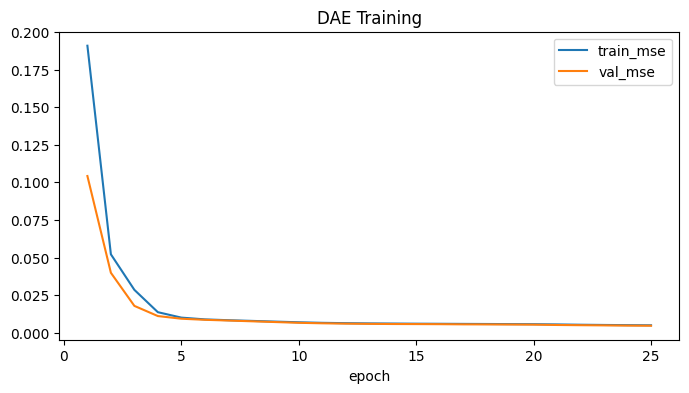

In [9]:
# Cell 11 — Train the denoising autoencoder
loader = DataLoader(
    TensorDataset(torch.tensor(Xa_fit, dtype=torch.float32)),
    batch_size=512 if torch.cuda.is_available() else 256,
    shuffle=True
)

opt = torch.optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

val_t = torch.tensor(Xa_val, dtype=torch.float32, device=DEVICE)

best_loss = np.inf
best_state = None
history = []

for epoch in range(1, AE_EPOCHS + 1):
    ae.train()
    losses = []

    for (batch,) in loader:
        batch = batch.to(DEVICE)
        noisy = torch.clamp(
            batch + 0.05 * torch.randn_like(batch),
            0.0, 1.0
        )

        opt.zero_grad()
        rec = ae(noisy)
        loss = loss_fn(rec, batch)
        loss.backward()
        opt.step()

        losses.append(loss.item())

    ae.eval()
    with torch.no_grad():
        val_loss = loss_fn(ae(val_t), val_t).item()

    history.append([epoch, np.mean(losses), val_loss])

    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in ae.state_dict().items()
        }

    if epoch == 1 or epoch % 10 == 0 or epoch == AE_EPOCHS:
        print(epoch, history[-1])

ae.load_state_dict(best_state)

pd.DataFrame(
    history, columns=["epoch", "train_mse", "val_mse"]
).plot(
    x="epoch", y=["train_mse", "val_mse"],
    figsize=(8,4), title="DAE Training"
)
plt.show()


In [10]:
# Cell 12 — Encode 6D latent representation
def encode(model, X):
    model.eval()
    x = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        z = model.encoder(x)
    return z.cpu().numpy()

Ztr6 = encode(ae, Xtr_ae)
Zte6 = encode(ae, Xte_ae)

print(Ztr6.shape, Zte6.shape)


(82332, 6) (175341, 6)


In [11]:
# Cell 13 — Balanced diagnostic sample selection
def balanced_indices(y, n_per_class, seed):
    rng = np.random.default_rng(seed)
    out = []
    for c in np.unique(y):
        ids = np.flatnonzero(y == c)
        out.extend(rng.choice(ids, size=min(n_per_class, len(ids)), replace=False))
    out = np.array(out)
    rng.shuffle(out)
    return out

train_idx = balanced_indices(y_train, TRAIN_PER_CLASS, SEED)
test_idx = balanced_indices(y_test, TEST_PER_CLASS, SEED + 1)

print("Train diagnostic set:", len(train_idx), np.bincount(y_train[train_idx]))
print("Test diagnostic set :", len(test_idx), np.bincount(y_test[test_idx]))


Train diagnostic set: 80 [40 40]
Test diagnostic set : 200 [100 100]


In [12]:
# Cell 14 — Latent scaling for 4Q and 6Q experiments
SCALED = {}

for nq in QUBIT_OPTIONS:
    scaler = MinMaxScaler((0, np.pi))
    Ztr_q = scaler.fit_transform(Ztr6[:, :nq])
    Zte_q = scaler.transform(Zte6[:, :nq])

    Ztr_q = np.clip(Ztr_q, 0, np.pi)
    Zte_q = np.clip(Zte_q, 0, np.pi)

    SCALED[nq] = {
        "Xtrain": Ztr_q[train_idx],
        "ytrain": y_train[train_idx],
        "Xtest": Zte_q[test_idx],
        "ytest": y_test[test_idx],
        "scaler": scaler
    }

    print(nq, SCALED[nq]["Xtrain"].shape)


4 (80, 4)
6 (80, 6)


# Cell 15 — Kernel diagnostics

A classifier can fail even when code executes correctly. Therefore we diagnose the kernel itself.

The notebook computes:

- **Centered kernel-target alignment (CKTA)**  
  Higher positive values indicate better alignment between the kernel geometry and class labels.

- **Within-class similarity**  
  Mean kernel value for sample pairs with the same label.

- **Between-class similarity**  
  Mean kernel value for sample pairs with different labels.

- **Separation = within − between**

- **Kernel variance**  
  Very small variance can indicate kernel concentration.

- **Eigenvalue spectrum / effective rank**

- **Condition number**

These diagnostics help distinguish optimizer failure from a fundamentally uninformative quantum feature map.

In [13]:
# Cell 16 — Kernel diagnostic functions
def center_matrix(A):
    n = A.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ A @ H

def centered_alignment(K, y):
    ypm = 2 * np.asarray(y).reshape(-1) - 1
    Y = np.outer(ypm, ypm)
    Kc = center_matrix(K)
    Yc = center_matrix(Y)
    denom = np.linalg.norm(Kc, "fro") * np.linalg.norm(Yc, "fro")
    return float(np.sum(Kc * Yc) / denom) if denom > 0 else np.nan

def kernel_diagnostics(K, y):
    y = np.asarray(y)
    same = y[:, None] == y[None, :]
    diff = ~same

    # remove diagonal from same-class calculation
    same_no_diag = same & (~np.eye(len(y), dtype=bool))

    within = float(K[same_no_diag].mean())
    between = float(K[diff].mean())
    eig = eigvalsh((K + K.T) / 2)
    eig_pos = np.clip(eig, 0, None)

    s = eig_pos.sum()
    p = eig_pos / s if s > 0 else eig_pos
    effective_rank = float(np.exp(-np.sum(p[p > 0] * np.log(p[p > 0])))) if s > 0 else 0.0

    positive = eig_pos[eig_pos > 1e-10]
    condition = (
        float(positive.max() / positive.min())
        if len(positive) >= 2 else np.inf
    )

    return {
        "alignment": centered_alignment(K, y),
        "within_class": within,
        "between_class": between,
        "separation": within - between,
        "kernel_variance": float(np.var(K)),
        "min_eigenvalue": float(eig.min()),
        "max_eigenvalue": float(eig.max()),
        "effective_rank": effective_rank,
        "condition_number": condition
    }

def classification_metrics(y, p):
    pred = (np.asarray(p) >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "mcc": matthews_corrcoef(y, pred),
        "roc_auc": roc_auc_score(y, p),
        "pr_auc": average_precision_score(y, p),
        "predicted_positive_rate": float(pred.mean())
    }


In [14]:
# Cell 17 — Baseline fixed quantum kernel sanity check
BASELINE_ROWS = []

for nq in QUBIT_OPTIONS:
    d = SCALED[nq]

    fmap = zz_feature_map(
        feature_dimension=nq,
        reps=1,
        entanglement="linear"
    )

    kernel = FidelityStatevectorKernel(
        feature_map=fmap,
        enforce_psd=True
    )

    t0 = time.time()
    K_train = kernel.evaluate(d["Xtrain"])
    K_test = kernel.evaluate(d["Xtest"], d["Xtrain"])
    sec = time.time() - t0

    diag = kernel_diagnostics(K_train, d["ytrain"])

    svc = SVC(
        kernel="precomputed",
        probability=True,
        class_weight="balanced",
        random_state=SEED
    )
    svc.fit(K_train, d["ytrain"])
    p = svc.predict_proba(K_test)[:, 1]

    row = {
        "variant": f"Fixed_QK_{nq}Q",
        "qubits": nq,
        "optimizer": "none",
        "parameterization": "fixed",
        "init": np.nan,
        "runtime_sec": sec,
        **diag,
        **classification_metrics(d["ytest"], p)
    }
    BASELINE_ROWS.append(row)

baseline_df = pd.DataFrame(BASELINE_ROWS)
display(baseline_df)


,variant,qubits,optimizer,parameterization,init,runtime_sec,alignment,within_class,between_class,separation,...,condition_number,accuracy,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,predicted_positive_rate
0,Fixed_QK_4Q,4,none,fixed,NaN,0.727246,0.253217,0.303737,0.172243,0.131494,...,2.340669e+11,0.775,0.831325,0.69,0.754098,0.775,0.558124,0.9149,0.923970,0.415
1,Fixed_QK_6Q,6,none,fixed,NaN,1.018871,0.253723,0.205104,0.080829,0.124275,...,1.871210e+10,0.805,0.850575,0.74,0.791444,0.805,0.615221,0.9251,0.932102,0.435


In [15]:
# Cell 18 — Feature-map builder: shared vs per-qubit trainable rotations
def build_trainable_map(nq, parameterization="shared"):
    if parameterization == "shared":
        theta = ParameterVector("theta", 1)
        train_layer = QuantumCircuit(nq)
        for q in range(nq):
            train_layer.ry(theta[0], q)

    elif parameterization == "per_qubit":
        theta = ParameterVector("theta", nq)
        train_layer = QuantumCircuit(nq)
        for q in range(nq):
            train_layer.ry(theta[q], q)

    else:
        raise ValueError("parameterization must be 'shared' or 'per_qubit'")

    data_map = zz_feature_map(
        feature_dimension=nq,
        reps=1,
        entanglement="linear"
    )

    # Trainable layer BEFORE data-dependent feature map.
    fmap = train_layer.compose(data_map)

    return fmap, theta


In [16]:
# Cell 19 — Parameter-sensitivity test BEFORE optimization
SENSITIVITY_ROWS = []

for nq in QUBIT_OPTIONS:
    d = SCALED[nq]

    for parameterization in ["shared", "per_qubit"]:
        fmap, theta = build_trainable_map(nq, parameterization)

        candidate_points = [
            np.zeros(len(theta)),
            np.full(len(theta), np.pi/4),
            np.full(len(theta), np.pi/2),
            np.full(len(theta), 3*np.pi/4)
        ]

        matrices = []

        for i, point in enumerate(candidate_points):
            k = TrainableFidelityStatevectorKernel(
                feature_map=fmap,
                training_parameters=theta,
                enforce_psd=True
            )
            k.assign_training_parameters(point)
            K = k.evaluate(d["Xtrain"])
            matrices.append(K)

            diag = kernel_diagnostics(K, d["ytrain"])
            SENSITIVITY_ROWS.append({
                "qubits": nq,
                "parameterization": parameterization,
                "point_id": i,
                "point": point.tolist(),
                **diag
            })

        # Maximum Frobenius difference among tested parameter settings.
        max_delta = 0.0
        for i in range(len(matrices)):
            for j in range(i+1, len(matrices)):
                max_delta = max(
                    max_delta,
                    float(np.linalg.norm(matrices[i] - matrices[j], "fro"))
                )

        print(
            f"{nq}Q {parameterization}: "
            f"max parameter-induced kernel change = {max_delta:.6f}"
        )

sensitivity_df = pd.DataFrame(SENSITIVITY_ROWS)
display(sensitivity_df)


4Q shared: max parameter-induced kernel change = 65.421102
4Q per_qubit: max parameter-induced kernel change = 65.421102
6Q shared: max parameter-induced kernel change = 71.783728
6Q per_qubit: max parameter-induced kernel change = 71.783728


,qubits,parameterization,point_id,point,alignment,within_class,between_class,separation,kernel_variance,min_eigenvalue,max_eigenvalue,effective_rank,condition_number
0,4,shared,0,[0.0],0.253217,0.303737,0.172243,1.314939e-01,1.012672e-01,4.243169e-14,24.261721,9.039113,2.340669e+11
1,4,shared,1,[0.7853981633974483],0.175284,0.445093,0.374034,7.105954e-02,6.650063e-02,4.041987e-15,34.287837,6.431212,2.902418e+11
2,4,shared,2,[1.5707963267948966],0.108053,1.000000,1.000000,-1.110223e-16,4.683862e-32,-2.367603e-14,80.000000,1.000000,inf
3,4,shared,3,[2.356194490192345],0.175284,0.445093,0.374034,7.105954e-02,6.650063e-02,2.808233e-15,34.287837,6.431212,2.902459e+11
4,4,per_qubit,0,"[0.0, 0.0, 0.0, 0.0]",0.253217,0.303737,0.172243,1.314939e-01,1.012672e-01,4.243169e-14,24.261721,9.039113,2.340669e+11
5,4,per_qubit,1,"[0.7853981633974483, 0.7853981633974483, 0.785...",0.175284,0.445093,0.374034,7.105954e-02,6.650063e-02,4.041987e-15,34.287837,6.431212,2.902418e+11
6,4,per_qubit,2,"[1.5707963267948966, 1.5707963267948966, 1.570...",0.108053,1.000000,1.000000,-1.110223e-16,4.683862e-32,-2.367603e-14,80.000000,1.000000,inf
7,4,per_qubit,3,"[2.356194490192345, 2.356194490192345, 2.35619...",0.175284,0.445093,0.374034,7.105954e-02,6.650063e-02,2.808233e-15,34.287837,6.431212,2.902459e+11
8,6,shared,0,[0.0],0.253723,0.205104,0.080829,1.242751e-01,8.756740e-02,6.530980e-11,15.738971,13.016836,1.871210e+10
9,6,shared,1,[0.7853981633974483],0.189644,0.323768,0.246098,7.767034e-02,7.122995e-02,1.264519e-11,25.121072,9.791877,2.091158e+11


# Cell 20 — Interpret the sensitivity test

Before training QKA, inspect Cell 19.

A healthy trainable feature map should show a non-trivial change in:
- kernel matrix,
- alignment,
- separation,
- or kernel variance

as the trainable parameter changes.

If `max parameter-induced kernel change` is almost zero, the parameterization is effectively useless for fidelity-kernel training and should be rejected before running an optimizer.

In [17]:
# Cell 21 — Optimizer callback containers
class SPSACallback:
    def __init__(self):
        self.rows = []

    def __call__(self, nfev, x, fval, stepsize, accepted):
        self.rows.append({
            "nfev": nfev,
            "fval": float(fval),
            "stepsize": float(stepsize) if stepsize is not None else np.nan,
            "accepted": bool(accepted),
            "point": np.asarray(x).tolist()
        })

class GenericObjectiveRecorder:
    def __init__(self):
        self.rows = []

    def add(self, label, initial_point, final_point, initial_diag, final_diag, result):
        self.rows.append({
            "label": label,
            "initial_point": np.asarray(initial_point).tolist(),
            "final_point": np.asarray(final_point).tolist(),
            "initial_alignment": initial_diag["alignment"],
            "final_alignment": final_diag["alignment"],
            "initial_separation": initial_diag["separation"],
            "final_separation": final_diag["separation"],
            "optimal_value": float(result.optimal_value),
            "optimizer_evals": getattr(result, "optimizer_evals", np.nan),
            "optimizer_time": getattr(result, "optimizer_time", np.nan)
        })

objective_recorder = GenericObjectiveRecorder()


In [18]:
# Cell 22 — Reusable exact-statevector QKA trainer
def run_qka_exact(
    nq,
    parameterization,
    optimizer_name,
    initial_point,
    seed=42
):
    d = SCALED[nq]
    fmap, theta = build_trainable_map(nq, parameterization)

    kernel = TrainableFidelityStatevectorKernel(
        feature_map=fmap,
        training_parameters=theta,
        enforce_psd=True,
        shots=None
    )

    # Diagnose initialization.
    kernel.assign_training_parameters(initial_point)
    K0 = kernel.evaluate(d["Xtrain"])
    diag0 = kernel_diagnostics(K0, d["ytrain"])

    if optimizer_name == "COBYLA":
        optimizer = COBYLA(
            maxiter=COBYLA_ITERS,
            tol=1e-5
        )
        callback_data = None

    elif optimizer_name == "SPSA":
        callback_data = SPSACallback()
        optimizer = SPSA(
            maxiter=SPSA_ITERS,
            learning_rate=0.05,
            perturbation=0.05,
            callback=callback_data
        )
    else:
        raise ValueError("optimizer must be COBYLA or SPSA")

    trainer = QuantumKernelTrainer(
        quantum_kernel=kernel,
        loss="svc_loss",
        optimizer=optimizer,
        initial_point=initial_point
    )

    t0 = time.time()
    result = trainer.fit(d["Xtrain"], d["ytrain"])
    elapsed = time.time() - t0

    trained_kernel = result.quantum_kernel

    K_train = trained_kernel.evaluate(d["Xtrain"])
    K_test = trained_kernel.evaluate(d["Xtest"], d["Xtrain"])
    diag1 = kernel_diagnostics(K_train, d["ytrain"])

    svc = SVC(
        kernel="precomputed",
        probability=True,
        class_weight="balanced",
        random_state=seed
    )
    svc.fit(K_train, d["ytrain"])
    p = svc.predict_proba(K_test)[:, 1]

    metrics = classification_metrics(d["ytest"], p)

    row = {
        "variant": f"{nq}Q_{parameterization}_{optimizer_name}",
        "qubits": nq,
        "optimizer": optimizer_name,
        "parameterization": parameterization,
        "init": np.asarray(initial_point).tolist(),
        "final_point": np.asarray(result.optimal_point).tolist(),
        "optimal_svc_loss": float(result.optimal_value),
        "runtime_sec": elapsed,
        "initial_alignment": diag0["alignment"],
        "alignment": diag1["alignment"],
        "alignment_gain": diag1["alignment"] - diag0["alignment"],
        "initial_separation": diag0["separation"],
        "within_class": diag1["within_class"],
        "between_class": diag1["between_class"],
        "separation": diag1["separation"],
        "separation_gain": diag1["separation"] - diag0["separation"],
        "kernel_variance": diag1["kernel_variance"],
        "effective_rank": diag1["effective_rank"],
        "condition_number": diag1["condition_number"],
        **metrics
    }

    return row, result, trained_kernel, K0, K_train, callback_data


In [19]:
# Cell 23 — Repair R1: 4Q shared parameter + COBYLA multi-start
R1_ROWS = []
R1_CACHE = []

for init_scalar in INIT_POINTS_SHARED:
    print("R1 init =", init_scalar)
    row, result, kernel, K0, K1, cb = run_qka_exact(
        nq=4,
        parameterization="shared",
        optimizer_name="COBYLA",
        initial_point=[init_scalar],
        seed=SEED
    )
    R1_ROWS.append(row)
    R1_CACHE.append((row, result, kernel, K0, K1))

r1_df = pd.DataFrame(R1_ROWS).sort_values(
    ["roc_auc", "mcc", "f1"],
    ascending=False
)
display(r1_df)


R1 init = 0.0
R1 init = 0.7853981633974483
R1 init = 1.5707963267948966
R1 init = 2.356194490192345


,variant,qubits,optimizer,parameterization,init,final_point,optimal_svc_loss,runtime_sec,initial_alignment,alignment,...,condition_number,accuracy,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,predicted_positive_rate
2,4Q_shared_COBYLA,4,COBYLA,shared,[1.5707963267948966],[3.029246326794897],32.398614,3.871466,0.108053,0.251550,...,1.495647e+11,0.775,0.831325,0.69,0.754098,0.775,0.558124,0.9150,0.923633,0.415
0,4Q_shared_COBYLA,4,COBYLA,shared,[0.0],[0.11058499999999999],32.398582,4.681308,0.253217,0.251628,...,1.494563e+11,0.775,0.831325,0.69,0.754098,0.775,0.558124,0.9149,0.923624,0.415
1,4Q_shared_COBYLA,4,COBYLA,shared,[0.7853981633974483],[0.11054816339744826],32.398583,4.562997,0.175284,0.251629,...,1.494529e+11,0.775,0.831325,0.69,0.754098,0.775,0.558124,0.9149,0.923624,0.415
3,4Q_shared_COBYLA,4,COBYLA,shared,[2.356194490192345],[3.0310194901923446],32.398582,5.206198,0.175284,0.251628,...,1.494559e+11,0.775,0.831325,0.69,0.754098,0.775,0.558124,0.9149,0.923624,0.415


In [20]:
# Cell 24 — Repair R2: 4Q shared parameter + SPSA multi-start
R2_ROWS = []
R2_CACHE = []

for init_scalar in INIT_POINTS_SHARED:
    print("R2 init =", init_scalar)
    row, result, kernel, K0, K1, cb = run_qka_exact(
        nq=4,
        parameterization="shared",
        optimizer_name="SPSA",
        initial_point=[init_scalar],
        seed=SEED
    )
    R2_ROWS.append(row)
    R2_CACHE.append((row, result, kernel, K0, K1, cb))

r2_df = pd.DataFrame(R2_ROWS).sort_values(
    ["roc_auc", "mcc", "f1"],
    ascending=False
)
display(r2_df)


R2 init = 0.0
R2 init = 0.7853981633974483
R2 init = 1.5707963267948966
R2 init = 2.356194490192345


,variant,qubits,optimizer,parameterization,init,final_point,optimal_svc_loss,runtime_sec,initial_alignment,alignment,...,condition_number,accuracy,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,predicted_positive_rate
0,4Q_shared_SPSA,4,SPSA,shared,[0.0],[0.11293291620285117],32.398573,11.147229,0.253217,0.251524,...,1.496034e+11,0.775,0.831325,0.69,0.754098,0.775,0.558124,0.9149,0.923583,0.415
1,4Q_shared_SPSA,4,SPSA,shared,[0.7853981633974483],[0.11293291990666798],32.398633,10.968326,0.175284,0.251524,...,1.496029e+11,0.775,0.831325,0.69,0.754098,0.775,0.558124,0.9148,0.923535,0.415
2,4Q_shared_SPSA,4,SPSA,shared,[1.5707963267948966],[3.0286598256665105],32.398633,11.031821,0.108053,0.251524,...,1.496031e+11,0.775,0.831325,0.69,0.754098,0.775,0.558124,0.9148,0.923535,0.415
3,4Q_shared_SPSA,4,SPSA,shared,[2.356194490192345],[3.0286597336831322],32.398633,10.528737,0.175284,0.251524,...,1.496033e+11,0.775,0.831325,0.69,0.754098,0.775,0.558124,0.9148,0.923535,0.415


In [21]:
# Cell 25 — Repair R3: 6Q shared parameter + COBYLA multi-start
R3_ROWS = []
R3_CACHE = []

for init_scalar in INIT_POINTS_SHARED:
    print("R3 init =", init_scalar)
    row, result, kernel, K0, K1, cb = run_qka_exact(
        nq=6,
        parameterization="shared",
        optimizer_name="COBYLA",
        initial_point=[init_scalar],
        seed=SEED
    )
    R3_ROWS.append(row)
    R3_CACHE.append((row, result, kernel, K0, K1))

r3_df = pd.DataFrame(R3_ROWS).sort_values(
    ["roc_auc", "mcc", "f1"],
    ascending=False
)
display(r3_df)


R3 init = 0.0
R3 init = 0.7853981633974483
R3 init = 1.5707963267948966
R3 init = 2.356194490192345


,variant,qubits,optimizer,parameterization,init,final_point,optimal_svc_loss,runtime_sec,initial_alignment,alignment,...,condition_number,accuracy,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,predicted_positive_rate
0,6Q_shared_COBYLA,6,COBYLA,shared,[0.0],[-0.16962999999999998],29.538065,7.055570,0.253723,0.253080,...,1.672757e+10,0.815,0.853933,0.76,0.804233,0.815,0.633846,0.9224,0.928272,0.445
1,6Q_shared_COBYLA,6,COBYLA,shared,[0.7853981633974483],[-0.16959183660255173],29.538065,5.006898,0.189644,0.253081,...,1.672774e+10,0.815,0.853933,0.76,0.804233,0.815,0.633846,0.9224,0.928272,0.445
2,6Q_shared_COBYLA,6,COBYLA,shared,[1.5707963267948966],[3.3118463267948965],29.538071,7.252419,0.109234,0.253070,...,1.672530e+10,0.815,0.853933,0.76,0.804233,0.815,0.633846,0.9224,0.928255,0.445
3,6Q_shared_COBYLA,6,COBYLA,shared,[2.356194490192345],[3.311184490192345],29.538065,4.975629,0.189644,0.253081,...,1.672774e+10,0.815,0.853933,0.76,0.804233,0.815,0.633846,0.9224,0.928272,0.445


In [22]:
# Cell 26 — Choose the best optimizer from R1–R3
repair123 = pd.concat([r1_df, r2_df, r3_df], ignore_index=True)

best123 = repair123.sort_values(
    ["roc_auc", "mcc", "f1", "alignment"],
    ascending=False
).iloc[0]

BEST_OPTIMIZER = best123["optimizer"]

print("Best R1–R3 configuration:")
display(best123.to_frame().T)
print("Optimizer selected for R4:", BEST_OPTIMIZER)


Best R1–R3 configuration:


,variant,qubits,optimizer,parameterization,init,final_point,optimal_svc_loss,runtime_sec,initial_alignment,alignment,...,condition_number,accuracy,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,predicted_positive_rate
11,6Q_shared_COBYLA,6,COBYLA,shared,[2.356194490192345],[3.311184490192345],29.538065,4.975629,0.189644,0.253081,...,16727742629.479744,0.815,0.853933,0.76,0.804233,0.815,0.633846,0.9224,0.928272,0.445


Optimizer selected for R4: COBYLA


In [23]:
# Cell 27 — Repair R4: 6Q per-qubit parameters + best optimizer
# Use structured initializations rather than only one π/2 vector.
per_qubit_inits = [
    np.zeros(6),
    np.full(6, np.pi/4),
    np.full(6, np.pi/2),
    np.linspace(np.pi/8, 7*np.pi/8, 6)
]

R4_ROWS = []
R4_CACHE = []

for i, init in enumerate(per_qubit_inits):
    print("R4 initialization", i, init)

    row, result, kernel, K0, K1, cb = run_qka_exact(
        nq=6,
        parameterization="per_qubit",
        optimizer_name=BEST_OPTIMIZER,
        initial_point=init,
        seed=SEED
    )

    R4_ROWS.append(row)
    R4_CACHE.append((row, result, kernel, K0, K1, cb))

r4_df = pd.DataFrame(R4_ROWS).sort_values(
    ["roc_auc", "mcc", "f1"],
    ascending=False
)
display(r4_df)


R4 initialization 0 [0. 0. 0. 0. 0. 0.]
R4 initialization 1 [0.78539816 0.78539816 0.78539816 0.78539816 0.78539816 0.78539816]
R4 initialization 2 [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633]
R4 initialization 3 [0.39269908 0.86393798 1.33517688 1.80641578 2.27765467 2.74889357]


,variant,qubits,optimizer,parameterization,init,final_point,optimal_svc_loss,runtime_sec,initial_alignment,alignment,...,condition_number,accuracy,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,predicted_positive_rate
0,6Q_per_qubit_COBYLA,6,COBYLA,per_qubit,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.03785801264521149, 0.2183232790628058, 0.02...",29.048251,7.107453,0.253723,0.261741,...,2.771396e+10,0.820,0.855556,0.77,0.810526,0.820,0.643224,0.9252,0.929326,0.450
2,6Q_per_qubit_COBYLA,6,COBYLA,per_qubit,"[1.5707963267948966, 1.5707963267948966, 1.570...","[3.3176602134851545, 3.7177417877324967, 2.864...",28.855702,6.900836,0.109234,0.273266,...,2.566522e+10,0.835,0.894118,0.76,0.821622,0.835,0.677667,0.9146,0.925382,0.425
3,6Q_per_qubit_COBYLA,6,COBYLA,per_qubit,"[0.39269908169872414, 0.8639379797371931, 1.33...","[-0.6476484315342421, 0.2729469490675803, 3.17...",28.591365,5.718467,0.194321,0.262107,...,2.604365e+10,0.820,0.855556,0.77,0.810526,0.820,0.643224,0.9102,0.909905,0.450
1,6Q_per_qubit_COBYLA,6,COBYLA,per_qubit,"[0.7853981633974483, 0.7853981633974483, 0.785...","[-0.48284096574192437, 0.32292447982888395, -0...",28.745438,5.663051,0.189644,0.260587,...,2.863503e+10,0.825,0.857143,0.78,0.816754,0.825,0.652649,0.9094,0.910180,0.455


In [24]:
# Cell 28 — Compare all repaired QKA variants with fixed kernels
repair_df = pd.concat(
    [r1_df, r2_df, r3_df, r4_df],
    ignore_index=True
)

comparison_cols = [
    "variant", "qubits", "optimizer", "parameterization",
    "roc_auc", "pr_auc", "mcc", "f1",
    "predicted_positive_rate",
    "initial_alignment", "alignment", "alignment_gain",
    "separation", "kernel_variance",
    "effective_rank", "optimal_svc_loss", "runtime_sec"
]

display(
    repair_df[comparison_cols]
    .sort_values(["roc_auc", "mcc", "f1"], ascending=False)
)

print("\nFixed-kernel baselines:")
display(
    baseline_df[
        ["variant","qubits","roc_auc","pr_auc","mcc","f1",
         "alignment","separation","kernel_variance","effective_rank","runtime_sec"]
    ]
)


,variant,qubits,optimizer,parameterization,roc_auc,pr_auc,mcc,f1,predicted_positive_rate,initial_alignment,alignment,alignment_gain,separation,kernel_variance,effective_rank,optimal_svc_loss,runtime_sec
12,6Q_per_qubit_COBYLA,6,COBYLA,per_qubit,0.9252,0.929326,0.643224,0.810526,0.450,0.253723,0.261741,0.008018,0.128545,0.088499,12.167337,29.048251,7.107453
8,6Q_shared_COBYLA,6,COBYLA,shared,0.9224,0.928272,0.633846,0.804233,0.445,0.253723,0.253080,-0.000642,0.123305,0.086483,13.255684,29.538065,7.055570
9,6Q_shared_COBYLA,6,COBYLA,shared,0.9224,0.928272,0.633846,0.804233,0.445,0.189644,0.253081,0.063437,0.123306,0.086483,13.255640,29.538065,5.006898
10,6Q_shared_COBYLA,6,COBYLA,shared,0.9224,0.928255,0.633846,0.804233,0.445,0.109234,0.253070,0.143836,0.123296,0.086478,13.256395,29.538071,7.252419
11,6Q_shared_COBYLA,6,COBYLA,shared,0.9224,0.928272,0.633846,0.804233,0.445,0.189644,0.253081,0.063437,0.123306,0.086483,13.255640,29.538065,4.975629
0,4Q_shared_COBYLA,4,COBYLA,shared,0.9150,0.923633,0.558124,0.754098,0.415,0.108053,0.251550,0.143497,0.131545,0.100921,8.966424,32.398614,3.871466
4,4Q_shared_SPSA,4,SPSA,shared,0.9149,0.923583,0.558124,0.754098,0.415,0.253217,0.251524,-0.001693,0.131534,0.100919,8.965928,32.398573,11.147229
1,4Q_shared_COBYLA,4,COBYLA,shared,0.9149,0.923624,0.558124,0.754098,0.415,0.253217,0.251628,-0.001590,0.131577,0.100927,8.967909,32.398582,4.681308
2,4Q_shared_COBYLA,4,COBYLA,shared,0.9149,0.923624,0.558124,0.754098,0.415,0.175284,0.251629,0.076345,0.131578,0.100927,8.967940,32.398583,4.562997
3,4Q_shared_COBYLA,4,COBYLA,shared,0.9149,0.923624,0.558124,0.754098,0.415,0.175284,0.251628,0.076344,0.131577,0.100927,8.967919,32.398582,5.206198



Fixed-kernel baselines:


,variant,qubits,roc_auc,pr_auc,mcc,f1,alignment,separation,kernel_variance,effective_rank,runtime_sec
0,Fixed_QK_4Q,4,0.9149,0.923970,0.558124,0.754098,0.253217,0.131494,0.101267,9.039113,0.727246
1,Fixed_QK_6Q,6,0.9251,0.932102,0.615221,0.791444,0.253723,0.124275,0.087567,13.016836,1.018871


In [25]:
# Cell 29 — Automatic QKA health checks
def health_label(row):
    if (
        row["roc_auc"] >= 0.70 and
        row["mcc"] >= 0.30 and
        0.10 <= row["predicted_positive_rate"] <= 0.90
    ):
        return "HEALTHY"
    elif (
        row["roc_auc"] > 0.55 and
        row["mcc"] > 0.05
    ):
        return "PARTIAL"
    return "FAILED"

repair_df["health"] = repair_df.apply(health_label, axis=1)

health_table = repair_df[
    [
        "variant","init","roc_auc","mcc","f1",
        "predicted_positive_rate",
        "alignment_gain","separation",
        "optimal_svc_loss","health"
    ]
].sort_values(
    ["health","roc_auc","mcc"],
    ascending=[True,False,False]
)

display(health_table)

best_repair = repair_df.sort_values(
    ["roc_auc","mcc","f1"],
    ascending=False
).iloc[0]

print("\nBEST REPAIRED QKA:")
display(best_repair.to_frame().T)


,variant,init,roc_auc,mcc,f1,predicted_positive_rate,alignment_gain,separation,optimal_svc_loss,health
12,6Q_per_qubit_COBYLA,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0.9252,0.643224,0.810526,0.450,0.008018,0.128545,29.048251,HEALTHY
8,6Q_shared_COBYLA,[0.0],0.9224,0.633846,0.804233,0.445,-0.000642,0.123305,29.538065,HEALTHY
9,6Q_shared_COBYLA,[0.7853981633974483],0.9224,0.633846,0.804233,0.445,0.063437,0.123306,29.538065,HEALTHY
10,6Q_shared_COBYLA,[1.5707963267948966],0.9224,0.633846,0.804233,0.445,0.143836,0.123296,29.538071,HEALTHY
11,6Q_shared_COBYLA,[2.356194490192345],0.9224,0.633846,0.804233,0.445,0.063437,0.123306,29.538065,HEALTHY
0,4Q_shared_COBYLA,[1.5707963267948966],0.9150,0.558124,0.754098,0.415,0.143497,0.131545,32.398614,HEALTHY
4,4Q_shared_SPSA,[0.0],0.9149,0.558124,0.754098,0.415,-0.001693,0.131534,32.398573,HEALTHY
1,4Q_shared_COBYLA,[0.0],0.9149,0.558124,0.754098,0.415,-0.001590,0.131577,32.398582,HEALTHY
2,4Q_shared_COBYLA,[0.7853981633974483],0.9149,0.558124,0.754098,0.415,0.076345,0.131578,32.398583,HEALTHY
3,4Q_shared_COBYLA,[2.356194490192345],0.9149,0.558124,0.754098,0.415,0.076344,0.131577,32.398582,HEALTHY



BEST REPAIRED QKA:


,variant,qubits,optimizer,parameterization,init,final_point,optimal_svc_loss,runtime_sec,initial_alignment,alignment,...,accuracy,precision,recall,f1,balanced_accuracy,mcc,roc_auc,pr_auc,predicted_positive_rate,health
12,6Q_per_qubit_COBYLA,6,COBYLA,per_qubit,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.03785801264521149, 0.2183232790628058, 0.02...",29.048251,7.107453,0.253723,0.261741,...,0.82,0.855556,0.77,0.810526,0.82,0.643224,0.9252,0.929326,0.45,HEALTHY


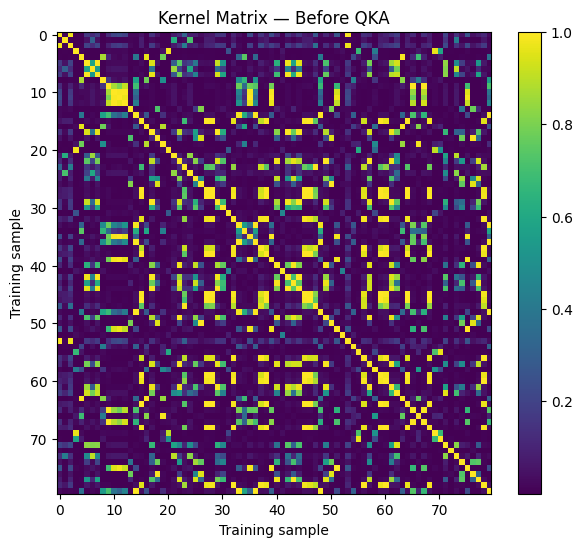

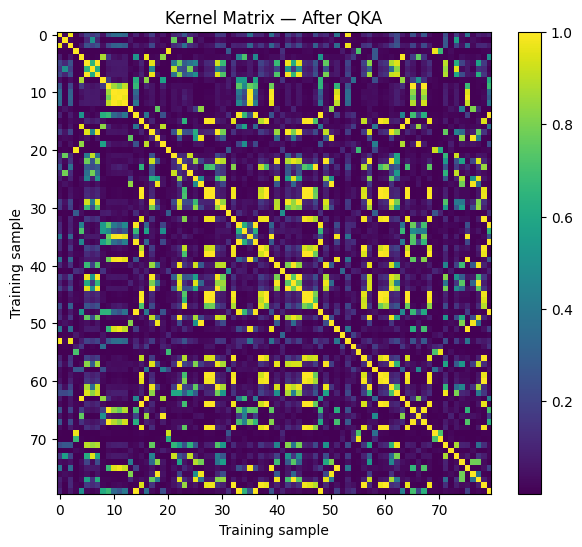

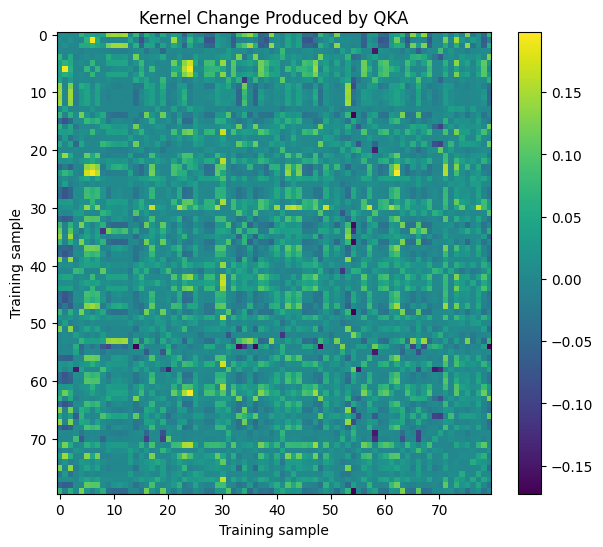

In [26]:
# Cell 30 — Visualize kernel matrices before and after repair
# Find the cached matrix corresponding to the overall best repair row.
best_variant = best_repair["variant"]
best_init = best_repair["init"]

all_cache = []
all_cache += [(x[0], x[3], x[4]) for x in R1_CACHE]
all_cache += [(x[0], x[3], x[4]) for x in R2_CACHE]
all_cache += [(x[0], x[3], x[4]) for x in R3_CACHE]
all_cache += [(x[0], x[3], x[4]) for x in R4_CACHE]

chosen = None
for row, K0, K1 in all_cache:
    if row["variant"] == best_variant and row["init"] == best_init:
        chosen = (K0, K1)
        break

if chosen is not None:
    K0, K1 = chosen

    plt.figure(figsize=(7,6))
    plt.imshow(K0, aspect="auto")
    plt.colorbar()
    plt.title("Kernel Matrix — Before QKA")
    plt.xlabel("Training sample")
    plt.ylabel("Training sample")
    plt.show()

    plt.figure(figsize=(7,6))
    plt.imshow(K1, aspect="auto")
    plt.colorbar()
    plt.title("Kernel Matrix — After QKA")
    plt.xlabel("Training sample")
    plt.ylabel("Training sample")
    plt.show()

    plt.figure(figsize=(7,6))
    plt.imshow(K1 - K0, aspect="auto")
    plt.colorbar()
    plt.title("Kernel Change Produced by QKA")
    plt.xlabel("Training sample")
    plt.ylabel("Training sample")
    plt.show()


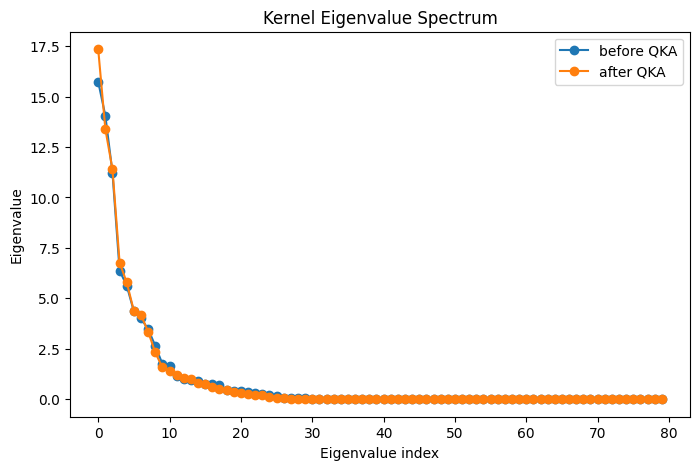

In [27]:
# Cell 31 — Eigenvalue-spectrum comparison
if chosen is not None:
    eig0 = np.sort(eigvalsh((K0 + K0.T)/2))[::-1]
    eig1 = np.sort(eigvalsh((K1 + K1.T)/2))[::-1]

    plt.figure(figsize=(8,5))
    plt.plot(eig0, marker="o", label="before QKA")
    plt.plot(eig1, marker="o", label="after QKA")
    plt.xlabel("Eigenvalue index")
    plt.ylabel("Eigenvalue")
    plt.title("Kernel Eigenvalue Spectrum")
    plt.legend()
    plt.show()


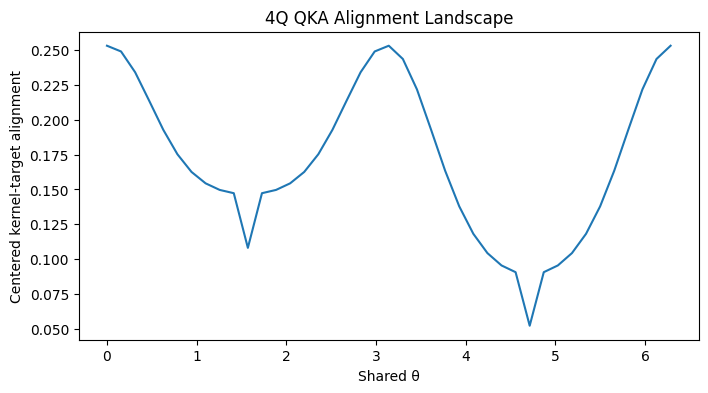

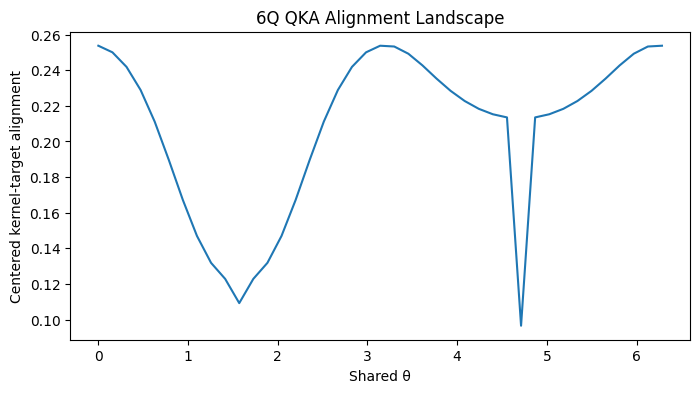

In [28]:
# Cell 32 — Alignment landscape for the shared-parameter kernel
# This is one of the most useful diagnostic plots.
# It shows whether the one-dimensional shared parameter has a meaningful landscape.

for nq in QUBIT_OPTIONS:
    d = SCALED[nq]
    fmap, theta = build_trainable_map(nq, "shared")

    grid = np.linspace(0, 2*np.pi, 41)
    rows = []

    for value in grid:
        k = TrainableFidelityStatevectorKernel(
            feature_map=fmap,
            training_parameters=theta,
            enforce_psd=True
        )
        k.assign_training_parameters([value])
        K = k.evaluate(d["Xtrain"])
        dg = kernel_diagnostics(K, d["ytrain"])
        rows.append([value, dg["alignment"], dg["separation"], dg["kernel_variance"]])

    landscape = pd.DataFrame(
        rows,
        columns=["theta","alignment","separation","variance"]
    )

    plt.figure(figsize=(8,4))
    plt.plot(landscape["theta"], landscape["alignment"])
    plt.xlabel("Shared θ")
    plt.ylabel("Centered kernel-target alignment")
    plt.title(f"{nq}Q QKA Alignment Landscape")
    plt.show()


In [29]:
# Cell 33 — Optional: test whether more ZZ repetitions help
# Keep this diagnostic separate from the main repair experiment.
# More circuit depth can improve expressivity but can also worsen concentration/noise.

DEPTH_ROWS = []

nq = 6
d = SCALED[nq]

for reps in [1, 2]:
    theta = ParameterVector(f"theta_depth_{reps}", 1)
    layer = QuantumCircuit(nq)
    for q in range(nq):
        layer.ry(theta[0], q)

    fmap = layer.compose(
        zz_feature_map(
            feature_dimension=nq,
            reps=reps,
            entanglement="linear"
        )
    )

    k = TrainableFidelityStatevectorKernel(
        feature_map=fmap,
        training_parameters=theta,
        enforce_psd=True
    )
    k.assign_training_parameters([np.pi/2])

    K = k.evaluate(d["Xtrain"])
    dg = kernel_diagnostics(K, d["ytrain"])

    DEPTH_ROWS.append({
        "qubits": nq,
        "zz_reps": reps,
        **dg
    })

depth_df = pd.DataFrame(DEPTH_ROWS)
display(depth_df)


,qubits,zz_reps,alignment,within_class,between_class,separation,kernel_variance,min_eigenvalue,max_eigenvalue,effective_rank,condition_number
0,6,1,0.109234,1.000000,1.000000,0.000000,1.540744e-31,-2.983632e-14,80.000000,1.000000,inf
1,6,2,0.253723,0.205104,0.080829,0.124275,8.756740e-02,6.531360e-11,15.738971,13.016836,1.871203e+10


In [30]:
# Cell 34 — Publication decision rule
best_fixed = baseline_df.sort_values(
    ["roc_auc","mcc","f1"],
    ascending=False
).iloc[0]

best_qka = repair_df.sort_values(
    ["roc_auc","mcc","f1"],
    ascending=False
).iloc[0]

decision = {
    "best_fixed_variant": best_fixed["variant"],
    "best_fixed_roc_auc": float(best_fixed["roc_auc"]),
    "best_fixed_mcc": float(best_fixed["mcc"]),
    "best_fixed_f1": float(best_fixed["f1"]),
    "best_qka_variant": best_qka["variant"],
    "best_qka_optimizer": best_qka["optimizer"],
    "best_qka_parameterization": best_qka["parameterization"],
    "best_qka_roc_auc": float(best_qka["roc_auc"]),
    "best_qka_mcc": float(best_qka["mcc"]),
    "best_qka_f1": float(best_qka["f1"]),
    "best_qka_alignment_gain": float(best_qka["alignment_gain"]),
    "best_qka_health": health_label(best_qka),
}

display(pd.DataFrame([decision]))

if decision["best_qka_health"] == "HEALTHY":
    print("RECOMMENDATION: QKA is repaired. Reinsert the best configuration into PAPER_FULL.")
elif decision["best_qka_health"] == "PARTIAL":
    print("RECOMMENDATION: QKA improved but needs one more targeted tuning stage.")
else:
    print("RECOMMENDATION: Do NOT reinsert QKA yet. Keep Fixed-QK and investigate feature-map design.")


,best_fixed_variant,best_fixed_roc_auc,best_fixed_mcc,best_fixed_f1,best_qka_variant,best_qka_optimizer,best_qka_parameterization,best_qka_roc_auc,best_qka_mcc,best_qka_f1,best_qka_alignment_gain,best_qka_health
0,Fixed_QK_6Q,0.9251,0.615221,0.791444,6Q_per_qubit_COBYLA,COBYLA,per_qubit,0.9252,0.643224,0.810526,0.008018,HEALTHY


RECOMMENDATION: QKA is repaired. Reinsert the best configuration into PAPER_FULL.


In [31]:
# Cell 35 — Save all QKA diagnostic outputs
import joblib, shutil

OUT = Path("/content/QKA_Repair_Results")
OUT.mkdir(exist_ok=True)

baseline_df.to_csv(OUT / "fixed_kernel_baseline.csv", index=False)
sensitivity_df.to_csv(OUT / "parameter_sensitivity.csv", index=False)
r1_df.to_csv(OUT / "R1_4Q_shared_COBYLA.csv", index=False)
r2_df.to_csv(OUT / "R2_4Q_shared_SPSA.csv", index=False)
r3_df.to_csv(OUT / "R3_6Q_shared_COBYLA.csv", index=False)
r4_df.to_csv(OUT / "R4_6Q_perqubit_bestoptimizer.csv", index=False)
repair_df.to_csv(OUT / "all_qka_repair_results.csv", index=False)
health_table.to_csv(OUT / "qka_health_table.csv", index=False)
depth_df.to_csv(OUT / "depth_diagnostic.csv", index=False)

pd.DataFrame({
    "selected_feature": selected_features
}).to_csv(OUT / "selected_features_used.csv", index=False)

with open(OUT / "repair_decision.json", "w") as f:
    json.dump(decision, f, indent=2)

joblib.dump(preprocessor, OUT / "preprocessor.joblib")
joblib.dump(ae_scaler, OUT / "ae_scaler.joblib")
torch.save(ae.state_dict(), OUT / "dae_6latent.pt")

print("Saved:", OUT)
for f in sorted(OUT.iterdir()):
    print(" -", f.name)


Saved: /content/QKA_Repair_Results
 - R1_4Q_shared_COBYLA.csv
 - R2_4Q_shared_SPSA.csv
 - R3_6Q_shared_COBYLA.csv
 - R4_6Q_perqubit_bestoptimizer.csv
 - ae_scaler.joblib
 - all_qka_repair_results.csv
 - dae_6latent.pt
 - depth_diagnostic.csv
 - fixed_kernel_baseline.csv
 - parameter_sensitivity.csv
 - preprocessor.joblib
 - qka_health_table.csv
 - repair_decision.json
 - selected_features_used.csv


In [32]:
# Cell 36 — Zip and download QKA repair results
from google.colab import files

zip_path = shutil.make_archive(
    "/content/QKA_Repair_Results",
    "zip",
    "/content/QKA_Repair_Results"
)

print(zip_path)
files.download(zip_path)


/content/QKA_Repair_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cell 37 — How to interpret the repair experiment

### Case A — Shared-parameter QKA works
If R1/R2/R3 show:
- ROC-AUC > 0.70,
- MCC > 0.30,
- non-constant predictions,
- positive alignment/separation change,

then use the best shared-parameter configuration in the publication notebook.

### Case B — Fixed kernel remains strong but every QKA version fails
Then the conclusion is not “quantum kernels fail.” It means the **trainable kernel parameterization/objective is not beneficial for this representation**. Keep Fixed-QK in the main paper and report QKA as an optimization limitation.

### Case C — Per-qubit R4 fails while shared-parameter QKA works
This strongly supports the hypothesis that the Paper Core QKA had too many poorly conditioned trainable degrees of freedom for the available low-data optimization budget.

### Case D — Alignment improves but classification does not
Then optimize the SVC decision layer, class weighting, and kernel regularization, because the learned kernel geometry may be improving without translating into calibrated test probabilities.

### Case E — Kernel variance is extremely small and effective rank collapses
This suggests kernel concentration. Reduce feature-map depth, change encoding scale, or test a different feature map rather than simply increasing optimizer iterations.

After running this notebook, upload:
- `all_qka_repair_results.csv`
- `fixed_kernel_baseline.csv`
- `parameter_sensitivity.csv`
- `repair_decision.json`

Those four files are sufficient to decide the exact QKA configuration for PAPER_FULL.